## **Naive Bayes pada Dataset Iris**

### 1. Pendahuluan
Proyek ini bertujuan untuk membangun model klasifikasi menggunakan algoritma **Naive Bayes** dengan library **scikit-learn**. Analisis dilakukan pada dataset Iris untuk memprediksi spesies bunga berdasarkan fitur morfologinya.

#### 1.1 Algoritma Gaussian Naive Bayes
Algoritma ini didasarkan pada **Teorema Bayes** dengan asumsi bahwa fitur-fitur bersifat independen satu sama lain. Varian **Gaussian** digunakan karena fitur pada dataset Iris bersifat kontinu (numerik), sehingga probabilitas dihitung menggunakan distribusi normal:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma^2_y}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma^2_y}\right)$$

Di mana $\mu_y$ adalah rata-rata (mean) dan $\sigma^2_y$ adalah varians dari fitur $x_i$ untuk kelas $y$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load Dataset
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset Iris berhasil dimuat dengan 150 sampel.")
df.head()

ModuleNotFoundError: No module named 'sklearn'

### 2. Eksplorasi & Visualisasi Data
Tahap ini bertujuan untuk memahami distribusi dan hubungan antar fitur sebelum model dilatih.

#### 2.1 Distribusi Fitur per Kelas
Berdasarkan gambar **distribusi_fitur.png**, terlihat bahwa fitur **Petal Length** dan **Petal Width** memberikan pemisahan kelas yang paling jelas dibandingkan fitur Sepal.


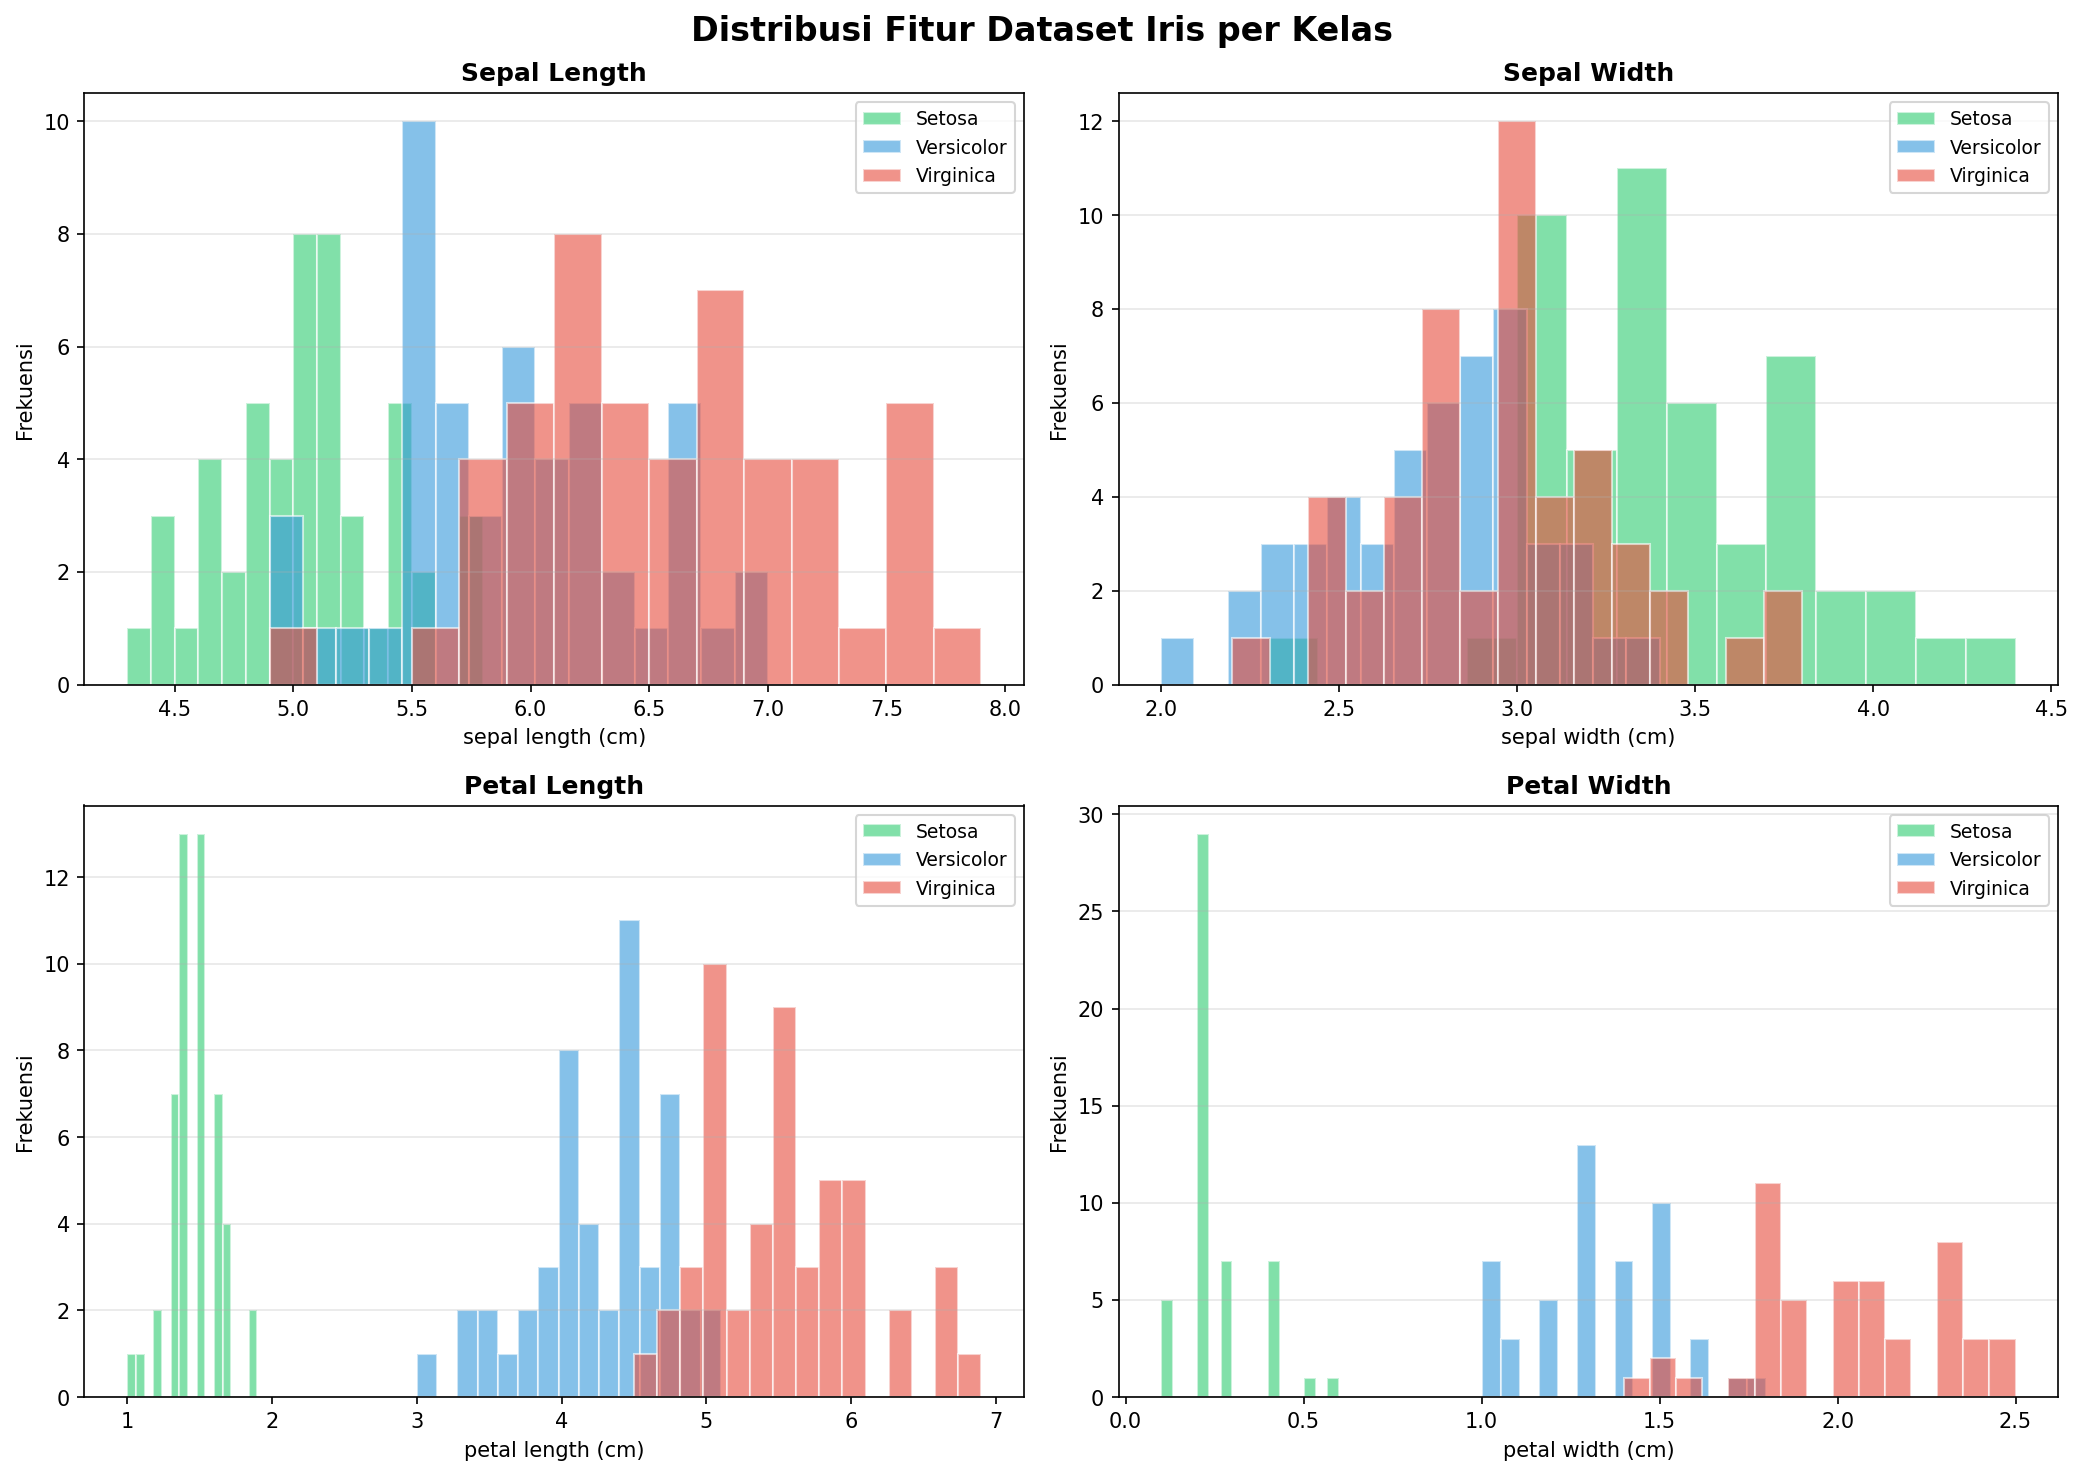

#### 2.2 Hubungan Antar Fitur (Scatter Plot)
Melalui scatter plot, kita dapat melihat pemisahan antar kelas, di mana spesies **Setosa** membentuk kelompok yang sangat terpisah (linearly separable), sedangkan **Versicolor** dan **Virginica** memiliki sedikit area yang saling tumpang tindih (overlap).


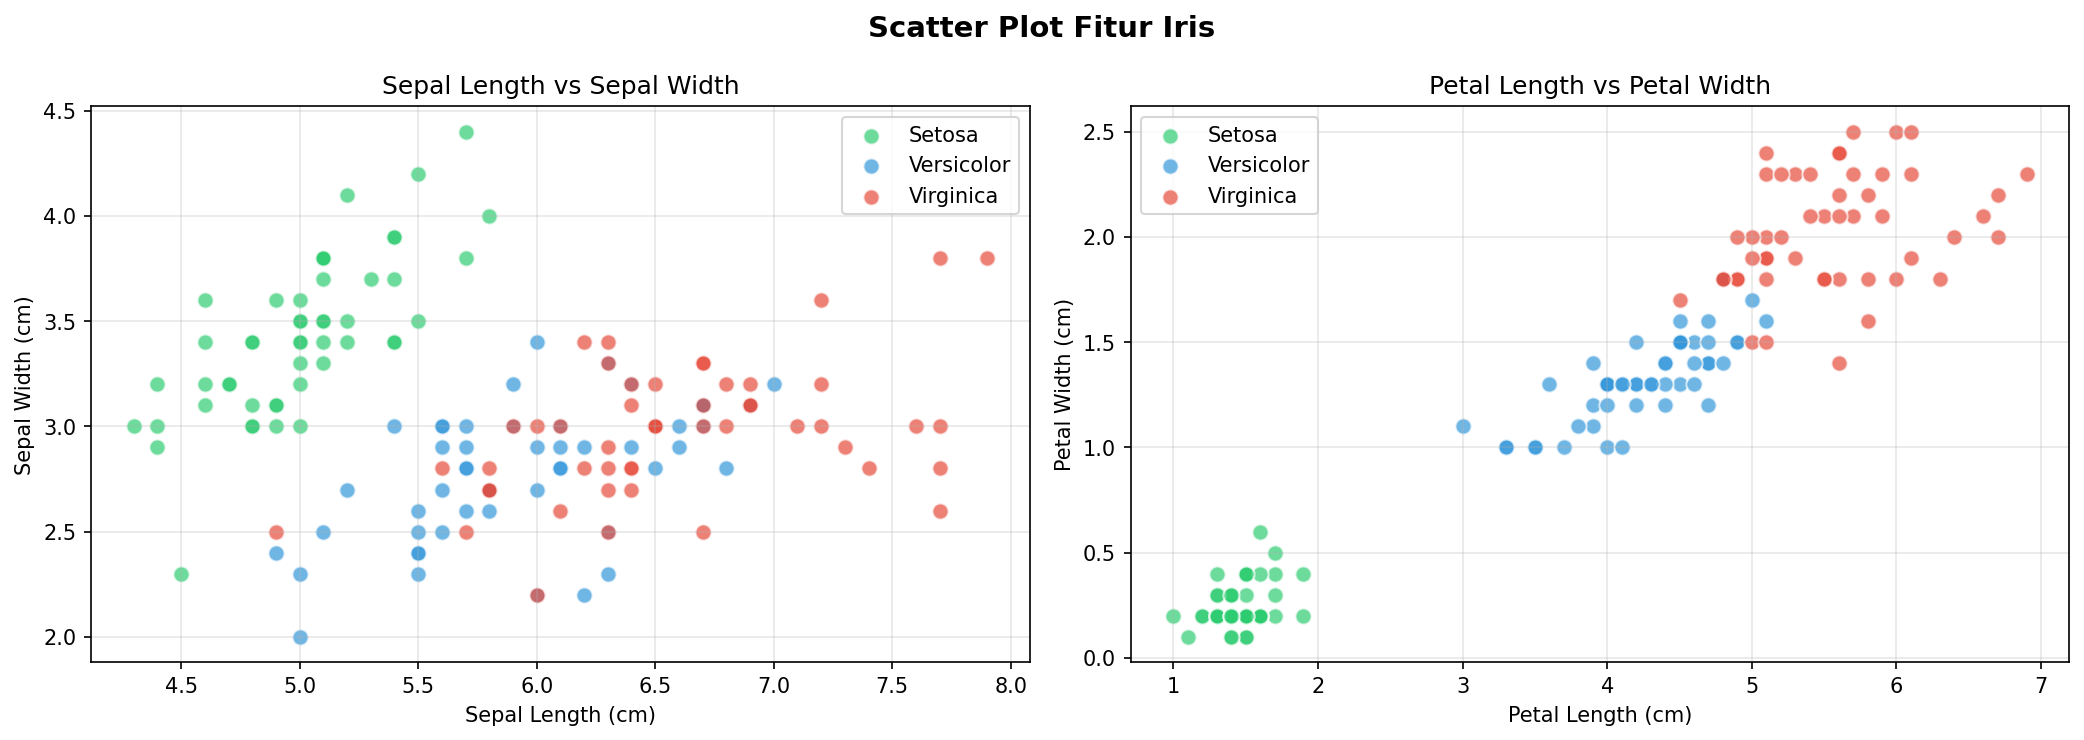

#### 2.3 Matriks Korelasi
Menunjukkan hubungan linear antar fitur numerik.
Meskipun Naive Bayes mengasumsikan independensi, gambar korelasi_fitur menunjukkan korelasi kuat (0.96) antara panjang dan lebar petal. Namun, Naive Bayes tetap bekerja dengan baik pada data ini


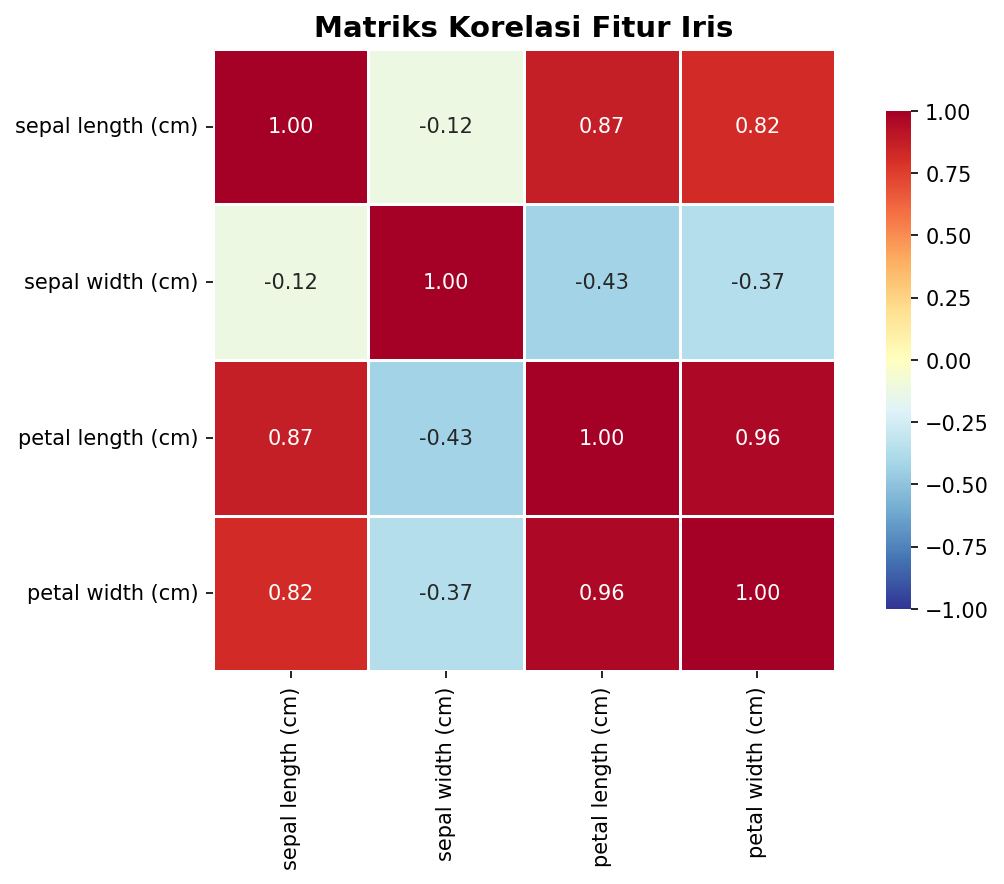

In [6]:
# 2. Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# 3. Inisialisasi dan Training Model
model = GaussianNB()
model.fit(X_train, y_train)

# 4. Prediksi pada data uji
y_pred = model.predict(X_test)

# Menampilkan parameter yang dipelajari (Mean)
mean_df = pd.DataFrame(model.theta_, columns=iris.feature_names, index=iris.target_names)
print("Rata-rata (Mean) yang dipelajari model untuk setiap kelas:")
display(mean_df)

Rata-rata (Mean) yang dipelajari model untuk setiap kelas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.990000,3.452500,1.450000,0.245000
versicolor,5.919512,2.770732,4.241463,1.321951
virginica,6.533333,2.966667,5.520513,2.000000


### 3. Evaluasi Model
Performa model diuji menggunakan 20% data sisa (data testing) untuk melihat akurasi dan detail klasifikasi.

#### 3.1 Confusion Matrix
Menunjukkan detail jumlah prediksi yang benar dan salah untuk setiap kelas.

Berdasarkan **confusion_matrix.png**, model berhasil mengklasifikasikan hampir seluruh data dengan benar:
*   **Setosa**: 10 sampel diprediksi benar (100%).
*   **Versicolor**: 9 sampel benar, 1 sampel salah prediksi sebagai Virginica.
*   **Virginica**: 10 sampel diprediksi benar (100%).


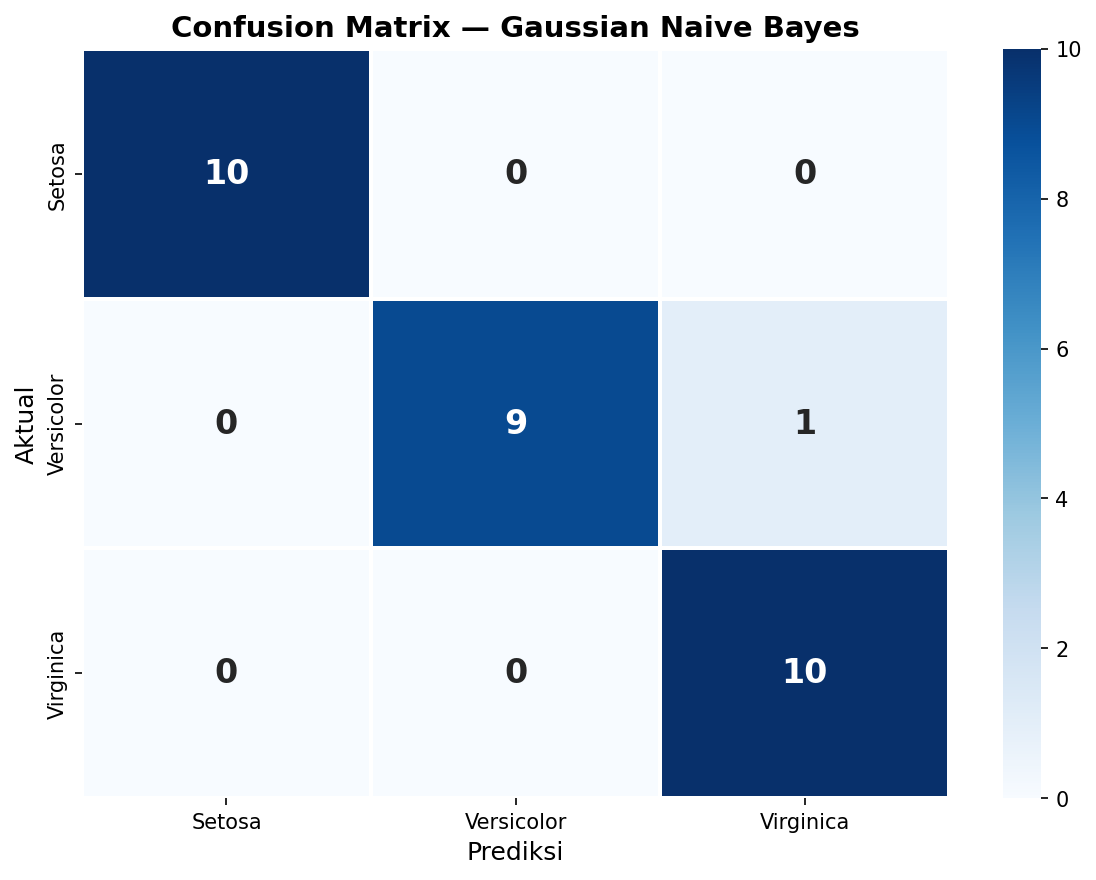

#### 3.2 Metrik Performa
Berdasarkan hasil pengujian, model mencapai akurasi yang sangat tinggi:
*   **Accuracy:** 0.9667
*   **Precision:** 0.9697
*   **Recall:** 0.9667
*   **F1-Score:** 0.9666

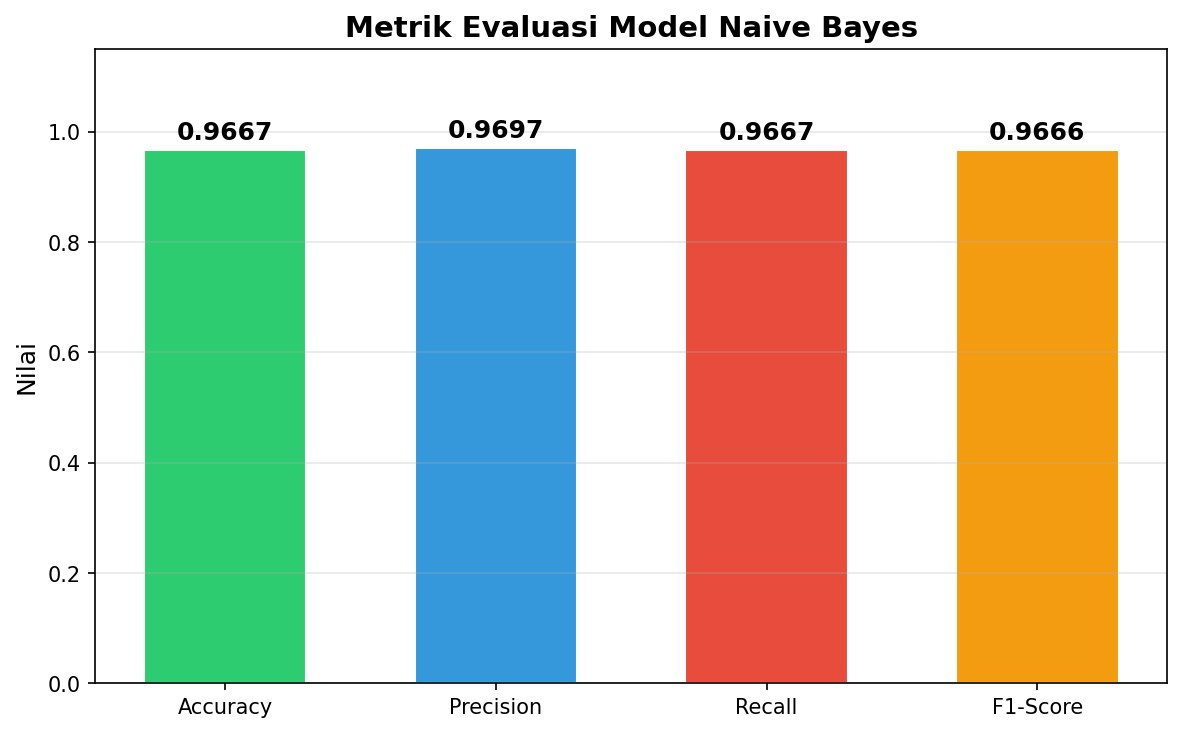

### 4. Analisis Probabilitas Prediksi
Model Naive Bayes tidak hanya memberikan label kelas, tetapi juga nilai probabilitas seberapa yakin model terhadap prediksi tersebut.
Visualisasi berikut menunjukkan tingkat keyakinan model (probability) dalam menentukan kelas untuk sampel tertentu.


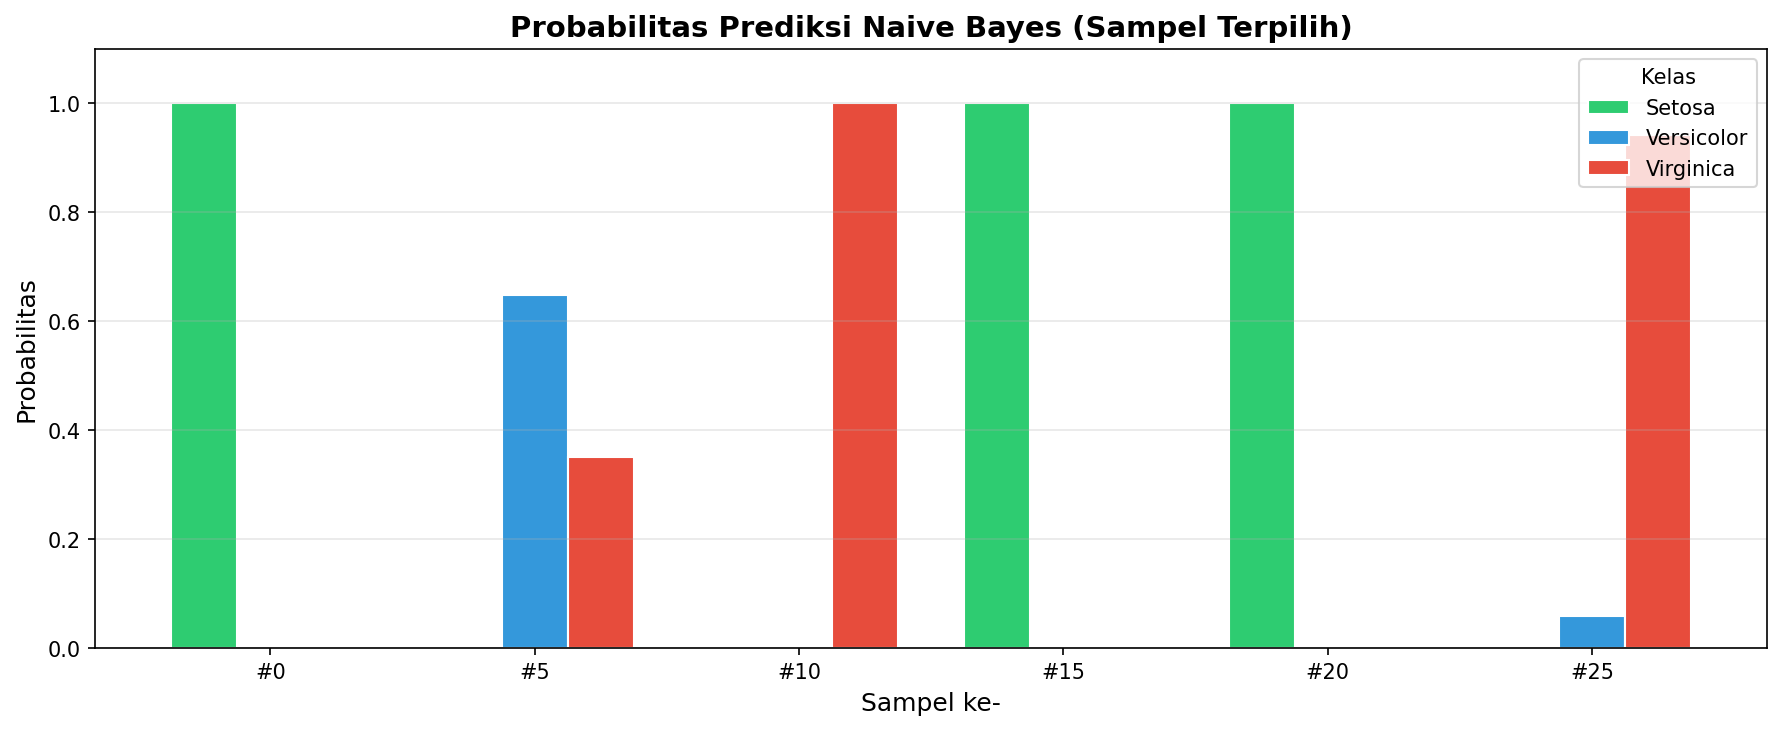

### 5. Kesimpulan
Algoritma **Gaussian Naive Bayes** terbukti sangat efektif untuk dataset Iris dengan akurasi di atas **96%**. Meskipun terdapat korelasi antar fitur petal, asumsi "Naive" tetap menghasilkan performa yang andal, Pemisahan kelas Setosa sangat sempurna, sementara sedikit error terjadi pada Versicolor/Virginica karena kemiripan ukuran fisik di area transisi.